# Cosmic-ray transport output analysis
Loads `ndis_C_transport_dR50_dz10_r1.03_dt1e4_v300_D3e28.bin` without copying the whole file into RAM.

The binary contains native float64 arrays in `(R, z)` order, including two ghost layers. It has **no metadata**; the settings below match the current C++ sources. Snapshots follow steps 1, 11, 21, …, not step 0. Repeated simulations append to the same file. Only select a second run if the first run completed all 1,000 snapshots.

Requires NumPy and Matplotlib. Density normalization is unspecified; integrated particle number is reported in code units for the positive-z half-domain.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm

FILE = Path("ndis_C_transport_dR50_dz10_r1.03_dt1e4_v300_D3e28.bin")
DT = 10_000.0                # yr
NT = 10_000
SAVE_EVERY = 10
NG = 2
D = 2e-7                     # kpc²/yr, current main.cpp (filename is only a label)
WIND = 3e-7                  # kpc/yr in each direction
RUN_INDEX = 0                # zero-based; each completed run has 1,000 snapshots
MAX_SNAPSHOTS = None          # optionally restrict analysis to a shorter interval


In [2]:
def capped_faces(lower, upper, first_width, max_width, ratio):
    # Match AxisGrid::geometric_capped, including its final full-cell overshoot.
    faces = [float(lower)]
    width = float(first_width)
    while faces[-1] < upper:
        faces.append(faces[-1] + width)
        width = max_width if width >= max_width / ratio else width * ratio
    return np.asarray(faces)

R_faces = capped_faces(0, 200, 0.05, 1.0, 1.03)
z_faces = capped_faces(0, 200, 0.01, 1.0, 1.03)
dR, dz = np.diff(R_faces), np.diff(z_faces)
R_center = (R_faces[:-1] + R_faces[1:]) / 2
R = R_center + dR**2 / (12 * R_center)  # cylindrical volume centroids
z = (z_faces[:-1] + z_faces[1:]) / 2
nR, nz = len(R), len(z)
volume = np.pi * np.diff(R_faces**2)[:, None] * dz[None, :]
initial = DT * np.exp(-(R[:, None]-10)**2/9 - (z[None, :]-10)**2/9)
initial_number = np.sum(initial * volume)

frame_shape = (nR + 2*NG, nz + 2*NG)
frame_bytes = np.prod(frame_shape).item() * np.dtype("=f8").itemsize
file_bytes = FILE.stat().st_size
n_complete, trailing_bytes = divmod(file_bytes, frame_bytes)
if n_complete == 0:
    raise ValueError("No complete snapshot: check file and grid settings.")
if trailing_bytes:
    print(f"Ignoring {trailing_bytes:,} trailing bytes (possibly a write in progress).")
frames_per_run = len(range(0, NT, SAVE_EVERY))
start = RUN_INDEX * frames_per_run
stop = min(start + frames_per_run, n_complete)
if MAX_SNAPSHOTS is not None:
    stop = min(stop, start + MAX_SNAPSHOTS)
if start < 0 or stop <= start:
    raise ValueError("Requested run has no complete snapshots.")
raw = np.memmap(FILE, dtype="=f8", mode="r", shape=(n_complete, *frame_shape))
density = raw[start:stop, NG:-NG, NG:-NG]  # view, excludes ghosts
steps = 1 + SAVE_EVERY * np.arange(len(density))
time_myr = steps * DT / 1e6
print(f"Grid: {nR} × {nz}; outer faces: {R_faces[-1]:.4f}, {z_faces[-1]:.4f} kpc")
print(f"File: {file_bytes/2**20:.1f} MiB; {n_complete} complete snapshots")
print(f"Selected run {RUN_INDEX}: {len(density)} snapshots, {time_myr[0]:.2f}–{time_myr[-1]:.2f} Myr")
if n_complete > frames_per_run:
    print("Extra snapshots detected. Check whether the file contains appended runs.")
print(f"D = {D:g} kpc²/yr; wind = {WIND:g} kpc/yr per direction")


Grid: 270 × 323; outer faces: 200.3151, 200.2007 kpc
File: 683.6 MiB; 1000 complete snapshots
Selected run 0: 1000 snapshots, 0.01–99.91 Myr
D = 2e-07 kpc²/yr; wind = 3e-07 kpc/yr per direction


## Particle number, spreading, and negative densities
Integrals use cylindrical cell volumes. The baseline is the Gaussian reconstructed from `initialization.cpp`, because no initial snapshot was saved. Absorbing boundaries allow particle loss. Signed densities are retained in diagnostics; negative values are not clipped.


Final N / initial N: 1
Minimum over saved states: 0
Nonfinite entries across saved states: 0


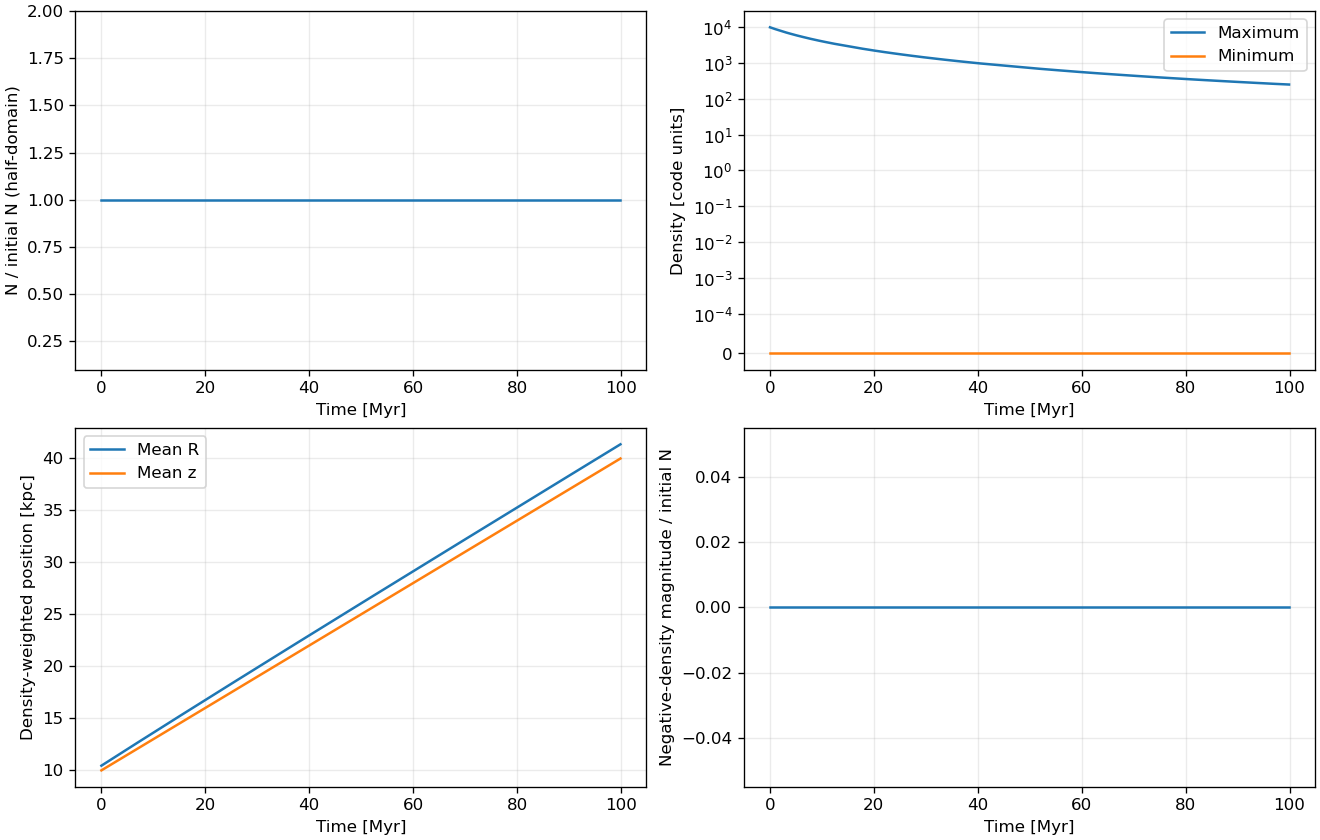

In [3]:
number = np.empty(len(density))
minimum = np.empty(len(density))
maximum = np.empty(len(density))
negative_number = np.empty(len(density))
mean_R = np.empty(len(density))
mean_z = np.empty(len(density))
nonfinite = np.zeros(len(density), dtype=int)
for k, frame in enumerate(density):
    nonfinite[k] = np.count_nonzero(~np.isfinite(frame))
    weighted = frame * volume
    number[k] = np.sum(weighted)
    minimum[k], maximum[k] = np.min(frame), np.max(frame)
    negative_number[k] = -np.sum(np.minimum(frame, 0) * volume)
    mean_R[k] = np.sum(weighted * R[:, None]) / number[k] if number[k] != 0 else np.nan
    mean_z[k] = np.sum(weighted * z[None, :]) / number[k] if number[k] != 0 else np.nan

fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
axes[0, 0].plot(time_myr, number / initial_number)
axes[0, 0].set_ylabel("N / initial N (half-domain)")
axes[0, 0].set_ylim(0.1,2)
axes[0, 1].plot(time_myr, maximum, label="Maximum")
axes[0, 1].plot(time_myr, minimum, label="Minimum")
axes[0, 1].set_yscale("symlog", linthresh=1e-8 * DT)
axes[0, 1].set_ylabel("Density [code units]")
axes[0, 1].legend()
axes[1, 0].plot(time_myr, mean_R, label="Mean R")
axes[1, 0].plot(time_myr, mean_z, label="Mean z")
axes[1, 0].set_ylabel("Density-weighted position [kpc]")
axes[1, 0].legend()
axes[1, 1].plot(time_myr, negative_number / initial_number)
axes[1, 1].set_ylabel("Negative-density magnitude / initial N")
for ax in axes.flat:
    ax.set_xlabel("Time [Myr]")
    ax.grid(alpha=0.25)
plt.show()
print(f"Final N / initial N: {number[-1]/initial_number:.8g}")
print(f"Minimum over saved states: {np.min(minimum):.8g}")
print(f"Nonfinite entries across saved states: {nonfinite.sum():,}")
if np.any(minimum < 0):
    print("Negative densities detected; signed moments should be interpreted with care.")


## Density maps
True cell edges are used for the nonuniform grid. Panels share a color scale. If a selected frame contains negative values, a signed scale displays them.


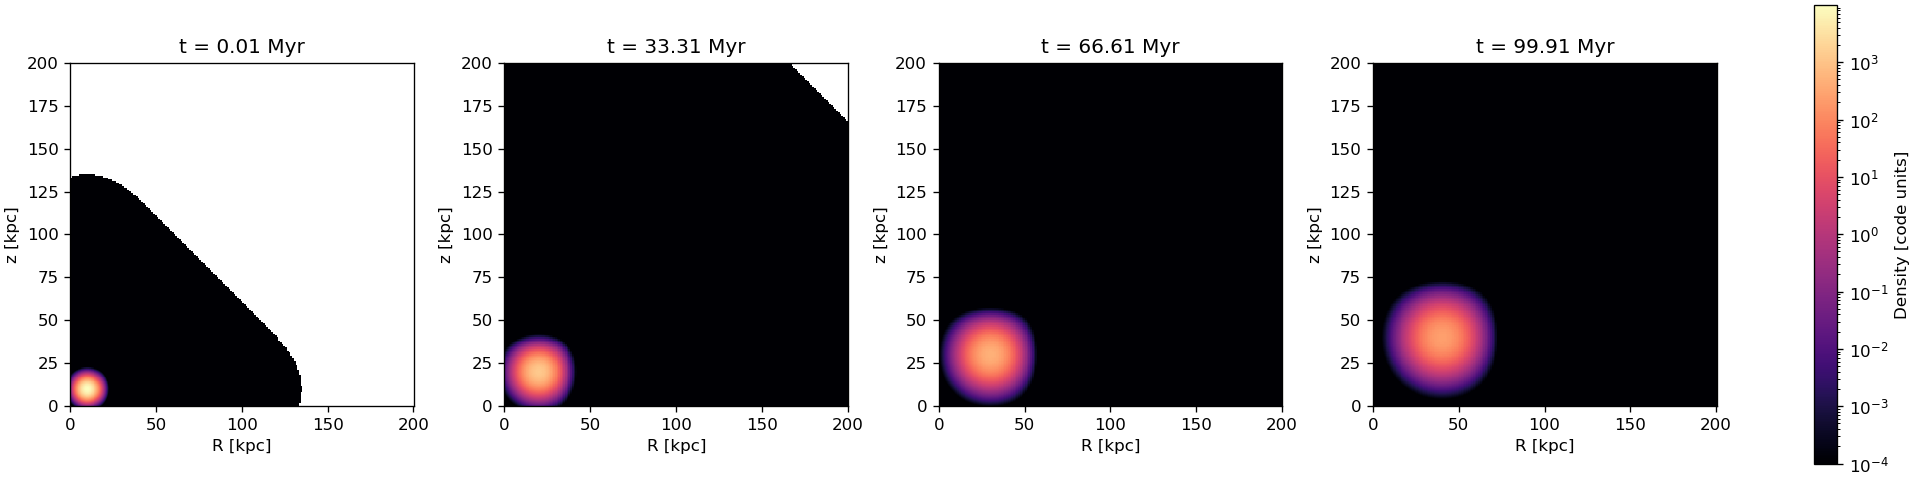

In [4]:
indices = np.unique(np.linspace(0, len(density)-1, 4, dtype=int))
frames = [np.asarray(density[k]) for k in indices]
if any(not np.all(np.isfinite(f)) for f in frames):
    raise ValueError("Selected maps contain nonfinite densities.")
scale = max(max(np.max(np.abs(f)) for f in frames), np.finfo(float).tiny)
signed = any(np.min(f) < 0 for f in frames)
norm = (SymLogNorm(linthresh=scale*1e-6, vmin=-scale, vmax=scale)
        if signed else LogNorm(vmin=scale*1e-8, vmax=scale))
fig, axes = plt.subplots(1, len(indices), figsize=(4*len(indices), 4),
                         squeeze=False, constrained_layout=True)
for ax, k, frame in zip(axes.flat, indices, frames):
    values = frame if signed else np.ma.masked_less_equal(frame, 0)
    mesh = ax.pcolormesh(R_faces, z_faces, values.T, shading="flat",
                         norm=norm, cmap="coolwarm" if signed else "magma")
    ax.set(title=f"t = {time_myr[k]:.2f} Myr", xlabel="R [kpc]", ylabel="z [kpc]")
    ax.set_aspect("equal")
fig.colorbar(mesh, ax=list(axes.flat), label="Density [code units]")
plt.show()


## Integrated radial and vertical profiles
Radial profiles integrate density over z. Vertical profiles integrate over annular area. These are distributions per unit R and z, respectively, rather than slices through a fixed coordinate.


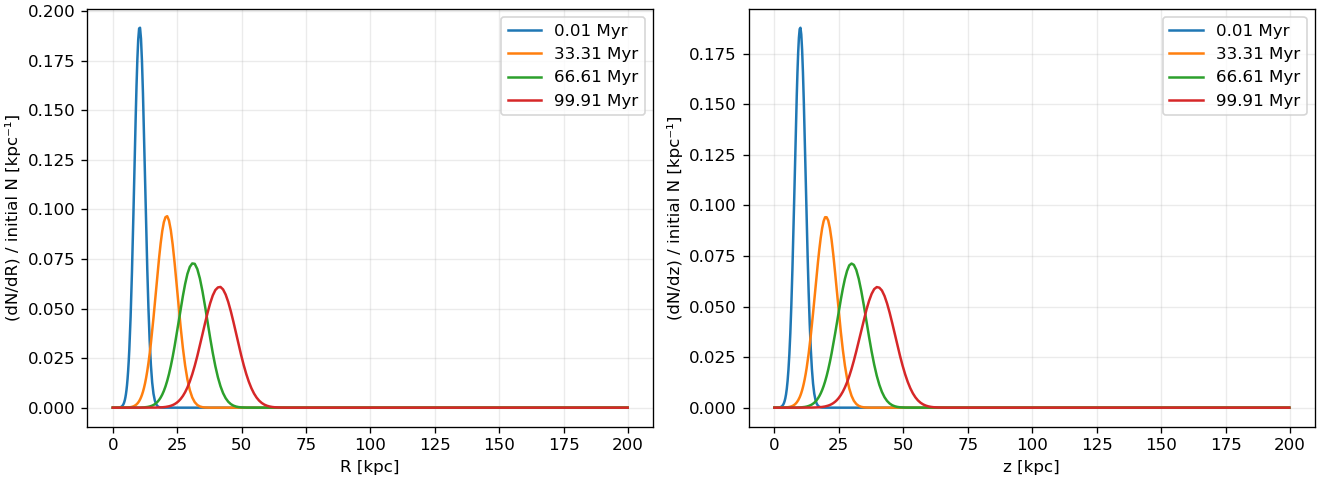

In [5]:
annular_area = np.pi * np.diff(R_faces**2)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for k in indices:
    frame = density[k]
    dN_dR = annular_area / dR * np.sum(frame * dz[None, :], axis=1)
    dN_dz = np.sum(frame * annular_area[:, None], axis=0)
    label = f"{time_myr[k]:.2f} Myr"
    axes[0].plot(R, dN_dR / initial_number, label=label)
    axes[1].plot(z, dN_dz / initial_number, label=label)
axes[0].set(xlabel="R [kpc]", ylabel="(dN/dR) / initial N [kpc⁻¹]")
axes[1].set(xlabel="z [kpc]", ylabel="(dN/dz) / initial N [kpc⁻¹]")
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.25)
plt.show()


## Comparison with expected transport
For the Gaussian exp[−(x−10)²/9], the Cartesian variance is 4.5 kpc². Away from boundaries, vertical advection gives ⟨z⟩ ≈ ⟨z⟩₀ + v_z t and diffusion gives Var(z) ≈ Var(z)₀ + 2Dt. At 99.91 Myr, the expected displacement is 29.973 kpc and added variance is 39.964 kpc².

Radial particle distributions are weighted by R: their initial mean is about 10.45 kpc, rather than 10 kpc. Cylindrical diffusion also gives d⟨R⟩/dt = v_R + D⟨1/R⟩ when boundary terms are negligible. The radial comparison below integrates ⟨1/R⟩ from the measured frames, so it is a consistency check rather than an independent exact solution. Radial variance need not equal vertical variance.

These tests characterize this output, not grid/time convergence or verification of the binary's undocumented physical parameters.


Relative particle-number change from first saved frame: -9.126e-14
Final mean z: 39.971274; expected 39.973013 kpc
Final mean R: 41.337540; moment check 41.345230 kpc
Final vertical variance: 44.250630; expected 44.463874 kpc²
Relative vertical variance discrepancy: -0.480%
Final vertical standard deviation: 6.6521 kpc


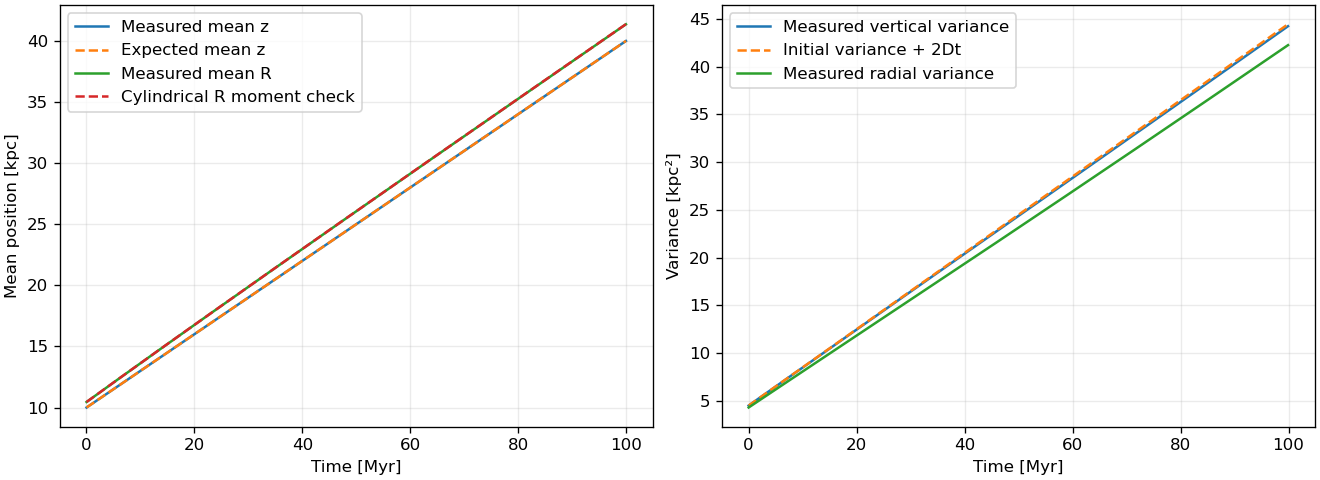

In [7]:
initial_weight = initial * volume
initial_mean_z = np.sum(initial_weight * z[None, :]) / initial_number
initial_var_z = np.sum(initial_weight * (z[None, :] - initial_mean_z)**2) / initial_number
initial_mean_R = np.sum(initial_weight * R[:, None]) / initial_number
initial_inverse_R = np.sum(initial_weight / R[:, None]) / initial_number
variance_z = np.empty(len(density))
variance_R = np.empty(len(density))
inverse_R = np.empty(len(density))
for k, frame in enumerate(density):
    weight = frame * volume
    variance_z[k] = np.sum(weight * (z[None, :] - mean_z[k])**2) / number[k]
    variance_R[k] = np.sum(weight * (R[:, None] - mean_R[k])**2) / number[k]
    inverse_R[k] = np.sum(weight / R[:, None]) / number[k]
t_years = time_myr * 1e6
expected_z = initial_mean_z + WIND * t_years
expected_variance_z = initial_var_z + 2 * D * t_years
all_t = np.r_[0, t_years]
all_inverse_R = np.r_[initial_inverse_R, inverse_R]
radial_diffusion_shift = D * np.cumsum(np.diff(all_t) * (all_inverse_R[1:] + all_inverse_R[:-1]) / 2)
expected_R = initial_mean_R + WIND * t_years + radial_diffusion_shift
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(time_myr, mean_z, label="Measured mean z")
axes[0].plot(time_myr, expected_z, "--", label="Expected mean z")
axes[0].plot(time_myr, mean_R, label="Measured mean R")
axes[0].plot(time_myr, expected_R, "--", label="Cylindrical R moment check")
axes[0].set(xlabel="Time [Myr]", ylabel="Mean position [kpc]")
axes[1].plot(time_myr, variance_z, label="Measured vertical variance")
axes[1].plot(time_myr, expected_variance_z, "--", label="Initial variance + 2Dt")
axes[1].plot(time_myr, variance_R, label="Measured radial variance")
axes[1].set(xlabel="Time [Myr]", ylabel="Variance [kpc²]")
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.25)
plt.show()
print(f"Relative particle-number change from first saved frame: {number[-1]/number[0]-1:.3e}")
print(f"Final mean z: {mean_z[-1]:.6f}; expected {expected_z[-1]:.6f} kpc")
print(f"Final mean R: {mean_R[-1]:.6f}; moment check {expected_R[-1]:.6f} kpc")
print(f"Final vertical variance: {variance_z[-1]:.6f}; expected {expected_variance_z[-1]:.6f} kpc²")
print(f"Relative vertical variance discrepancy: {variance_z[-1]/expected_variance_z[-1]-1:.3%}")
print(f"Final vertical standard deviation: {np.sqrt(variance_z[-1]):.4f} kpc")
